# 02 — Preprocessing: Curation and pIC50 Conversion

**Input:** `data/raw/btk_raw.csv` (6.502 records)  
**Output:** `data/processed/btk_curated.csv`  

Steps:
1. Load raw data
2. Filter: keep only exact IC50 values in nM
3. Remove missing SMILES and IC50
4. Convert IC50 → pIC50
5. Handle duplicate molecules (same compound, multiple assays)
6. Validate SMILES with RDKit
7. Assign activity labels (active / inactive)
8. Save curated dataset

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

INPUT_PATH  = '../data/raw/btk_raw.csv'
OUTPUT_PATH = '../data/processed/btk_curated.csv'
PICSO_THRESHOLD = 6.0  # pIC50 >= 6 → active (IC50 <= 1 µM)

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} records, {df.shape[1]} columns')

Loaded: 6502 records, 12 columns


## 2. Filter: Exact Values in nM Only

We keep only:
- `standard_relation == '='` → exact IC50, not a bound
- `standard_units == 'nM'` → consistent unit for conversion

In [2]:
df_filtered = df[
    (df['standard_relation'] == '=') &
    (df['standard_units'] == 'nM')
].copy()

print(f'After relation/unit filter: {len(df_filtered)} records')
print(f'Removed: {len(df) - len(df_filtered)} records')

After relation/unit filter: 5030 records
Removed: 1472 records


## 3. Remove Missing SMILES and IC50 Values

In [3]:
before = len(df_filtered)

df_filtered = df_filtered.dropna(subset=['canonical_smiles', 'standard_value'])
df_filtered = df_filtered[df_filtered['canonical_smiles'].str.strip() != '']

print(f'After removing missing SMILES/IC50: {len(df_filtered)} records')
print(f'Removed: {before - len(df_filtered)} records')

After removing missing SMILES/IC50: 5030 records
Removed: 0 records


## 4. Convert IC50 → pIC50

Formula: `pIC50 = -log10(IC50 × 10⁻⁹)`  
Since IC50 is in nM, we first convert to Molar by multiplying by 10⁻⁹.

In [4]:
df_filtered['standard_value'] = pd.to_numeric(df_filtered['standard_value'], errors='coerce')

# Remove non-positive IC50 values (log of zero/negative is undefined)
df_filtered = df_filtered[df_filtered['standard_value'] > 0]

# Convert nM → Molar → pIC50
df_filtered['pIC50'] = -np.log10(df_filtered['standard_value'] * 1e-9)

print(f'pIC50 range: {df_filtered["pIC50"].min():.2f} – {df_filtered["pIC50"].max():.2f}')
print(f'pIC50 mean:  {df_filtered["pIC50"].mean():.2f}')
print(f'Records:     {len(df_filtered)}')

pIC50 range: 2.00 – 10.30
pIC50 mean:  7.20
Records:     5029


## 5. Handle Duplicate Molecules

Some compounds appear in multiple assays with different IC50 values.  
Strategy: keep the **median pIC50** per molecule — more robust than mean to outlier assays.

In [5]:
before = len(df_filtered)

df_dedup = (
    df_filtered
    .groupby('molecule_chembl_id', as_index=False)
    .agg(
        canonical_smiles=('canonical_smiles', 'first'),
        pIC50=('pIC50', 'median'),
        n_assays=('assay_chembl_id', 'nunique')
    )
)

print(f'Before deduplication: {before} records')
print(f'After deduplication:  {len(df_dedup)} unique molecules')
print(f'Removed:              {before - len(df_dedup)} duplicate entries')
print(f'\nMolecules tested in more than 1 assay: {(df_dedup["n_assays"] > 1).sum()}')

Before deduplication: 5029 records
After deduplication:  4354 unique molecules
Removed:              675 duplicate entries

Molecules tested in more than 1 assay: 391


## 6. Validate SMILES with RDKit

RDKit tries to parse each SMILES string.  
If it returns `None`, the SMILES is invalid — we discard that molecule.

In [6]:
def is_valid_smiles(smi):
    """Returns True if RDKit can parse the SMILES."""
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol is not None
    except:
        return False

df_dedup['valid_smiles'] = df_dedup['canonical_smiles'].apply(is_valid_smiles)

invalid = (~df_dedup['valid_smiles']).sum()
print(f'Invalid SMILES: {invalid}')

df_valid = df_dedup[df_dedup['valid_smiles']].drop(columns='valid_smiles').reset_index(drop=True)
print(f'Valid molecules remaining: {len(df_valid)}')

Invalid SMILES: 0
Valid molecules remaining: 4354


## 7. Assign Activity Labels

Standard QSAR threshold:  
- `pIC50 >= 6.0` → **active** (IC50 ≤ 1 µM)  
- `pIC50 < 6.0`  → **inactive**

In [7]:
df_valid['activity'] = (df_valid['pIC50'] >= PICSO_THRESHOLD).astype(int)
# 1 = active, 0 = inactive

counts = df_valid['activity'].value_counts()
total  = len(df_valid)

print('=== Activity label distribution ===')
print(f'Active   (1): {counts.get(1, 0):>5}  ({counts.get(1, 0)/total*100:.1f}%)')
print(f'Inactive (0): {counts.get(0, 0):>5}  ({counts.get(0, 0)/total*100:.1f}%)')
print(f'Total:        {total}')

=== Activity label distribution ===
Active   (1):  3594  (82.5%)
Inactive (0):   760  (17.5%)
Total:        4354


## 8. Visualize pIC50 Distribution

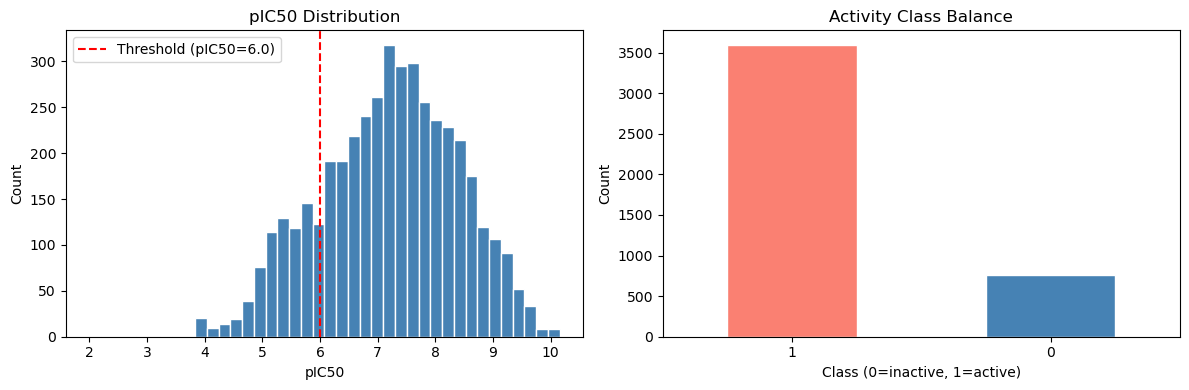

Plot saved to results/


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pIC50 distribution
axes[0].hist(df_valid['pIC50'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(x=PICSO_THRESHOLD, color='red', linestyle='--', label=f'Threshold (pIC50={PICSO_THRESHOLD})')
axes[0].set_title('pIC50 Distribution')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].legend()

# Activity class balance
counts.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title('Activity Class Balance')
axes[1].set_xlabel('Class (0=inactive, 1=active)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/02_picso_distribution.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 9. Save Curated Dataset

In [9]:
final_cols = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'activity', 'n_assays']
df_final = df_valid[final_cols]

df_final.to_csv(OUTPUT_PATH, index=False)
print(f'Curated dataset saved to {OUTPUT_PATH}')
print(f'Shape: {df_final.shape}')
print('\nFirst 3 rows:')
df_final.head(3)

Curated dataset saved to ../data/processed/btk_curated.csv
Shape: (4354, 5)

First 3 rows:


,molecule_chembl_id,canonical_smiles,pIC50,activity,n_assays
0,CHEMBL104468,O=c1cc(N2CCOCC2)oc2c1ccc1ccccc12,5.193820,0,3
1,CHEMBL1076864,CCN1CCN(c2ccc(NC(=O)Nc3ccc(-c4nc(N5C6CCC5COC6)...,8.920819,1,1
2,CHEMBL1078983,COc1ccc(-c2ccc3c(N4CCOCC4)nc(N4C[C@@H](C)O[C@@...,8.261439,1,6


## Observations and Curation Report

### Curation funnel

| Step | Records | Removed |
|------|---------|---------|
| Raw data loaded | 6.502 | — |
| After relation/unit filter (`=` in nM only) | 5.030 | 1.472 |
| After removing missing SMILES/IC50 | 5.030 | 0 |
| After deduplication (median pIC50 per molecule) | 4.354 | 675 |
| After RDKit SMILES validation | 4.354 | 0 |
| **Final curated dataset** | **4.354** | — |

### pIC50 statistics
- **Range:** 2.00 – 10.30
- **Mean:** 7.20
- A mean of 7.20 is high — it reflects the fact that BTK has several approved,
  highly potent drugs (ibrutinib, acalabrutinib), and the ChEMBL dataset is
  enriched with active compounds from medicinal chemistry campaigns.

### Data quality highlights
- **0 invalid SMILES** after RDKit validation — ChEMBL data for BTK is very clean.
- **391 molecules** were tested in more than one assay. For these, we kept the
  **median pIC50** across assays — more robust than the mean to outlier measurements.

### Class imbalance — important modeling consequence

After applying the standard QSAR threshold (pIC50 ≥ 6.0 = active):

| Class | Count | Percentage |
|-------|-------|------------|
| Active (1) | 3.594 | 82.5% |
| Inactive (0) | 760 | 17.5% |

The dataset is **imbalanced**: 82.5% of molecules are labeled active.

**Why this matters:** a naive model that predicts "active" for every molecule
would achieve 82.5% accuracy — without learning anything useful.
This means **accuracy is not a valid metric for this dataset**.

**What we will use instead:**
- **AUC-ROC:** measures the model's ability to rank actives above inactives,
  regardless of class proportion. A random classifier scores 0.5; a perfect one scores 1.0.
- **F1-score:** harmonic mean of precision and recall — penalizes models that
  ignore the minority class.
- **Recall for inactives:** critical in drug discovery — we do not want to
  miss inactive compounds and waste resources synthesizing and testing them.

**How we will handle it in modeling:**
- Use `class_weight='balanced'` in both Random Forest and SVM — this tells
  scikit-learn to penalize mistakes on the minority class (inactives) more heavily.
- Use **stratified k-fold cross-validation** to ensure every fold preserves
  the 82.5/17.5 ratio, avoiding folds where inactives are underrepresented.

## Summary

| Step | Records |
|------|---------|
| Raw data loaded | 6.502 |
| After relation/unit filter | *(see output)* |
| After missing value removal | *(see output)* |
| After deduplication | *(see output)* |
| After SMILES validation | *(see output)* |
| **Final curated dataset** | *(see output)* |

**Activity threshold:** pIC50 ≥ 6.0 (IC50 ≤ 1 µM)  
**Output:** `data/processed/btk_curated.csv`

**Next:** `03_fingerprints.ipynb` — Morgan fingerprint generation with RDKit.